# Bird or Drone? Image Classification Using KNN

## Student Details

- **Student:** Elizabetha A.
- **Last four digits of ID:** 1642

## Project Introduction

This project tests whether color, edge and grayscale features can distinguish birds from drones using K-Nearest Neighbors. Bird is treated as the positive class because the dataset contains fewer bird images than drone images. The models are compared using Bird F1-score, with accuracy and the confusion matrix reported as additional measures.

## Dataset Source

- **Dataset:** [Drone vs Bird: Aerial Object Classification Dataset](https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird?resource=download)
- **Source:** Kaggle

## Research Question

Can handcrafted color and edge features distinguish birds from drones?

## AI Assistance Disclosure

AI tools, including OpenAI Codex, were used for explanations of Python syntax, debugging support and notebook formatting.

### Representative prompts used during the project
1. ` אל תעשה את זה במקומי תסביר לי למה ואיך עובדת הפקודה?`
   - **Purpose:** Understand how the command works before using it.
2. `יש לי פה שגיאה במחברת תסביר לי מה לא עשיתי לא נכון`
   - **Purpose:** Locate the error and understand how to correct it.

## 1. Dataset Overview

The Kaggle dataset is organized into two class folders: bird and drone. The code below checks these folders and counts the supported image files in each class.

In [1]:
from pathlib import Path

DATASET_PATH = Path("dataset")

bird_folder = DATASET_PATH / "bird"
drone_folder = DATASET_PATH / "drone"

image_extensions = {".jpg", ".jpeg", ".png", ".webp"}

bird_images = [
    path for path in bird_folder.iterdir()
    if path.suffix.lower() in image_extensions
]

drone_images = [
    path for path in drone_folder.iterdir()
    if path.suffix.lower() in image_extensions
]

print("Number of bird images:", len(bird_images))
print("Number of drone images:", len(drone_images))
print("Total images:", len(bird_images) + len(drone_images))

Number of bird images: 1607
Number of drone images: 2499
Total images: 4106


### Initial observation

The dataset contains 4,106 images: 1,607 birds (39.1%) and 2,499 drones (60.9%). Birds are the smaller and central class, so Bird F1-score is used as the main evaluation metric. Accuracy and a confusion matrix are also reported.

During the later data split, source groups are assigned separately within each class. This keeps the class proportions similar across the training, validation and test sets while preventing related images from being placed in different subsets.

## 2. Visual Exploration

Random examples from each class are displayed to inspect image quality, backgrounds, lighting, object size and visible differences between birds and drones

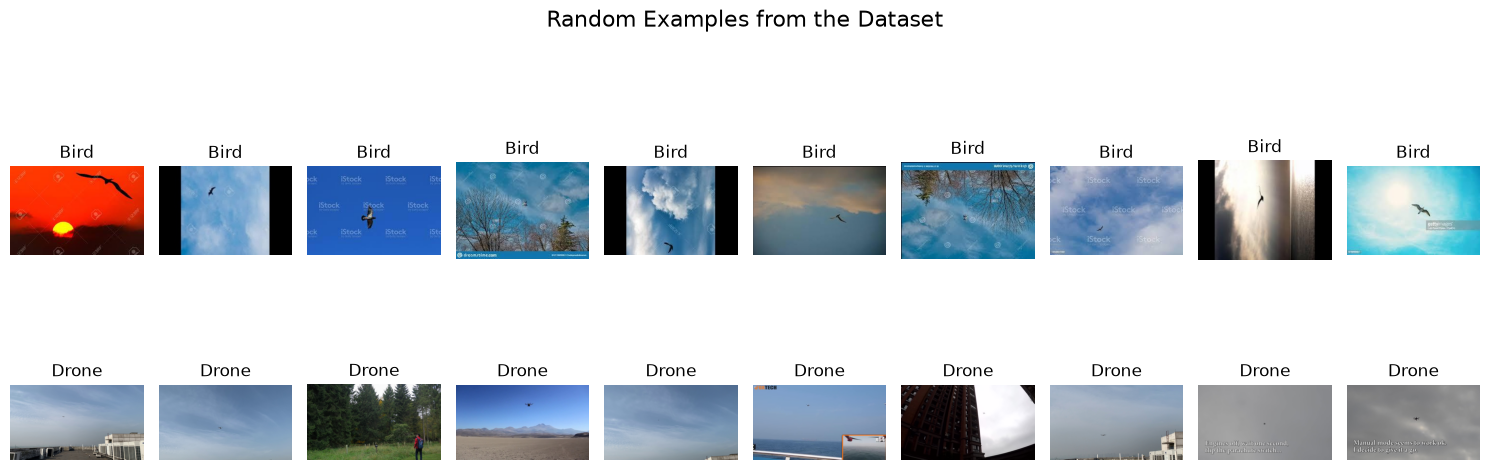

In [2]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

selected_birds = random.sample(bird_images, 10)
selected_drones = random.sample(drone_images, 10)

fig, axes = plt.subplots(2, 10, figsize=(15, 6))

for column, image_path in enumerate(selected_birds):
    with Image.open(image_path) as image:
        axes[0, column].imshow(image.convert("RGB"))

    axes[0, column].set_title("Bird")
    axes[0, column].axis("off")

for column, image_path in enumerate(selected_drones):
    with Image.open(image_path) as image:
        axes[1, column].imshow(image.convert("RGB"))

    axes[1, column].set_title("Drone")
    axes[1, column].axis("off")

plt.suptitle("Random Examples from the Dataset", fontsize=16)
plt.tight_layout()
plt.show()

### Visual Observations

The images vary considerably in orientation, resolution, lighting and object size. Birds are often shown as small silhouettes, and some bird images contain stock-photo watermarks. Several drone images appear to be consecutive frames from the same video, while in many examples the drone occupies only a small part of the image. Both classes frequently contain sky backgrounds, so color features alone may not be sufficient. Shape and edge features should therefore be examined. Consecutive or highly similar images must also be considered when creating the train and test sets, since placing similar frames in both sets could produce unrealistically high results.


In [3]:
import pandas as pd

image_information = []

for class_name, image_paths in [
    ("Bird", bird_images),
    ("Drone", drone_images)
]:
    for image_path in image_paths:
        with Image.open(image_path) as image:
            width, height = image.size

        if width > height:
            orientation = "Landscape"
        elif height > width:
            orientation = "Portrait"
        else:
            orientation = "Square"

        image_information.append({
            "class": class_name,
            "filename": image_path.name,
            "width": width,
            "height": height,
            "orientation": orientation
        })

images_df = pd.DataFrame(image_information)

images_df.head()

,class,filename,width,height,orientation
0,Bird,63.jpg,415,500,Portrait
1,Bird,singleBirdinsky36.jpeg,248,203,Landscape
2,Bird,singleBirdinsky128.jpg,275,183,Landscape
3,Bird,189.jpg,500,357,Landscape
4,Bird,singleBirdinsky398_r180.jpg,275,183,Landscape


In [4]:
images_df["aspect_ratio"] = (
    images_df["width"] / images_df["height"]
)

size_summary = images_df.groupby("class").agg(
    number_of_images=("filename", "count"),
    minimum_width=("width", "min"),
    median_width=("width", "median"),
    maximum_width=("width", "max"),
    minimum_height=("height", "min"),
    median_height=("height", "median"),
    maximum_height=("height", "max"),
    median_aspect_ratio=("aspect_ratio", "median")
)

size_summary

,number_of_images,minimum_width,median_width,maximum_width,minimum_height,median_height,maximum_height,median_aspect_ratio
class,,,,,,,,
Bird,1607,163,275.0,1600,134,188.0,1620,1.502732
Drone,2499,183,1920.0,4633,114,1080.0,3089,1.777778


In [5]:
orientation_summary = pd.crosstab(
    images_df["class"],
    images_df["orientation"],
    margins=True
)

orientation_summary

orientation,Landscape,Portrait,Square,All
class,,,,
Bird,1407,140,60,1607
Drone,2493,3,3,2499
All,3900,143,63,4106


### Image Size and Orientation Observations

The two classes differ considerably in their original image dimensions. The median bird image is 275×188 pixels, whereas the median drone image is 1920×1080 pixels. Almost all drone images are landscape-oriented, while the bird class contains more portrait and square images. Original width, height and aspect ratio will not be used as model features because they could allow the classifier to distinguish the image sources rather than the objects. All images will be converted to a consistent size before feature extraction.

In [6]:
invalid_images = []

for image_path in bird_images + drone_images:
    try:
        with Image.open(image_path) as image:
            image.verify()
    except Exception as error:
        invalid_images.append({
            "path": image_path,
            "error": str(error)
        })

print("Number of invalid images:", len(invalid_images))

Number of invalid images: 0


In [7]:
from collections import defaultdict
import hashlib

def calculate_file_hash(image_path):
    file_hash = hashlib.sha256()

    with open(image_path, "rb") as image_file:
        for chunk in iter(lambda: image_file.read(1024 * 1024), b""):
            file_hash.update(chunk)

    return file_hash.hexdigest()


hash_to_images = defaultdict(list)

for image_path in bird_images + drone_images:
    image_hash = calculate_file_hash(image_path)
    hash_to_images[image_hash].append(image_path)


duplicate_groups = [
    paths
    for paths in hash_to_images.values()
    if len(paths) > 1
]

number_of_duplicate_copies = sum(
    len(paths) - 1
    for paths in duplicate_groups
)

print("Duplicate groups:", len(duplicate_groups))
print("Extra duplicate copies:", number_of_duplicate_copies)
print("Unique images:", len(hash_to_images))

Duplicate groups: 384
Extra duplicate copies: 414
Unique images: 3692


In [8]:
unique_image_paths = sorted(
    [paths[0] for paths in hash_to_images.values()],
    key=str
)

clean_bird_images = [
    path for path in unique_image_paths
    if path.parent.name == "bird"
]

clean_drone_images = [
    path for path in unique_image_paths
    if path.parent.name == "drone"
]

print("Unique bird images:", len(clean_bird_images))
print("Unique drone images:", len(clean_drone_images))
print(
    "Total unique images:",
    len(clean_bird_images) + len(clean_drone_images)
)

Unique bird images: 1254
Unique drone images: 2438
Total unique images: 3692


### Duplicate Removal

The dataset contained 384 groups of exact duplicate files, representing 414 unnecessary copies. Using these duplicates could cause data leakage if identical images appeared in both the training and test sets. Therefore, one representative image from each duplicate group was retained. No original files were deleted. After exact duplicate removal, the working dataset contains 3,692 unique images.

In [9]:
import re

DRONE_FRAME_BLOCK_SIZE = 50

def get_source_group(image_path):
    stem = image_path.stem
    class_name = image_path.parent.name

    if class_name == "bird":
        match = re.match(
            r"singleBirdinsky(\d+)",
            stem,
            flags=re.IGNORECASE
        )

        if match:
            source_number = int(match.group(1))
            return f"bird_source_{source_number}"

        if stem.isdigit():
            return f"bird_source_{int(stem)}"

        return f"bird_{stem}"

    # Consecutive drone frames are placed in blocks of 50.
    if stem.isdigit() and len(stem) >= 10:
        return f"drone_long_sequence_{int(stem) // DRONE_FRAME_BLOCK_SIZE}"

    if stem.isdigit() and len(stem) == 6 and stem.startswith("10"):
        return f"drone_100_sequence_{int(stem) // DRONE_FRAME_BLOCK_SIZE}"

    match = re.match(r"img_plane(\d+)_", stem)
    if match:
        return f"drone_plane_{match.group(1)}"

    match = re.match(r"video(\d+)_", stem)
    if match:
        return f"drone_video_{match.group(1)}"

    if stem.lower().startswith("foto"):
        return "drone_foto_sequence"

    return f"drone_{stem}"

### Source-Group Heuristic

Since the dataset does not provide video identifiers, sequential Drone filenames were treated as an indication that nearby images may come from the same video.

To reduce the risk of data leakage, sequential Drone frames were conservatively grouped into blocks of 50 images. All images in the same block were assigned to the same dataset split and cross-validation fold. The block size is based on filenames rather than verified video metadata. It reduces the risk of related frames appearing in different subsets but cannot eliminate it completely.

For Bird images, augmented versions that share the same source number were assigned to the same source group.

In [10]:
clean_records = []

for image_path in clean_bird_images:
    clean_records.append({
        "path": image_path,
        "class": "Bird",
        "label": 1,
        "source_group": get_source_group(image_path)
    })

for image_path in clean_drone_images:
    clean_records.append({
        "path": image_path,
        "class": "Drone",
        "label": 0,
        "source_group": get_source_group(image_path)
    })

clean_df = pd.DataFrame(clean_records)

display(clean_df.head())

print(
    clean_df.groupby("class")["source_group"]
    .nunique()
)

,path,class,label,source_group
0,dataset/bird/100.jpg,Bird,1,bird_source_100
1,dataset/bird/101.jpg,Bird,1,bird_source_101
2,dataset/bird/102.jpg,Bird,1,bird_source_102
3,dataset/bird/103.jpg,Bird,1,bird_source_103
4,dataset/bird/104.jpg,Bird,1,bird_source_104


class
Bird     394
Drone    402
Name: source_group, dtype: int64


In [11]:
import numpy as np

def assign_group_splits(dataframe, seed=42):
    random_generator = np.random.default_rng(seed)
    group_assignments = {}

    for class_name in ["Bird", "Drone"]:
        class_data = dataframe[
            dataframe["class"] == class_name
        ]

        group_sizes = (
            class_data.groupby("source_group")
            .size()
        )

        groups = group_sizes.index.to_numpy(copy=True)
        random_generator.shuffle(groups)

        test_target = len(class_data) * 0.20
        validation_target = len(class_data) * 0.16

        test_count = 0
        validation_count = 0

        for group in groups:
            group_size = int(group_sizes[group])

            if test_count < test_target:
                split = "test"
                test_count += group_size

            elif validation_count < validation_target:
                split = "validation"
                validation_count += group_size

            else:
                split = "train"

            group_assignments[group] = split

    return dataframe["source_group"].map(group_assignments)


clean_df["split"] = assign_group_splits(clean_df)

In [12]:
split_summary = pd.crosstab(
    clean_df["split"],
    clean_df["class"],
    margins=True
)

display(split_summary)

groups_in_multiple_splits = (
    clean_df.groupby("source_group")["split"]
    .nunique()
    .gt(1)
    .sum()
)

print(
    "Source groups appearing in multiple splits:",
    groups_in_multiple_splits
)

assert groups_in_multiple_splits == 0

class,Bird,Drone,All
split,,,
test,253,524,777
train,800,1489,2289
validation,201,425,626
All,1254,2438,3692


Source groups appearing in multiple splits: 0


### Group-Aware Data Split

The Kaggle dataset does not provide predefined training and test subsets. After removing exact duplicates, the 3,692 remaining images were divided into training, validation and test sets using source groups rather than individual images. Augmented versions of the same bird image and nearby frames from the same drone sequence were kept in one subset. The training set contains 2,289 images, the validation set contains 626 images and the test set contains 777 images. No source group appears in more than one subset.

## 3. Image Preprocessing

All images are corrected according to their EXIF orientation and converted
to a consistent color mode before feature extraction.

For spatial representations, including grayscale pixels and edge features,
each image is resized while preserving its original aspect ratio. The resized
image is centered on a 64×64 canvas, and padding is filled using the image's
average color. The result is then reduced to 16×16 pixels for feature
extraction. This avoids stretching the object and changing its geometric
shape.

For HSV color histograms, images are resized directly to 64×64 pixels.
Because a global color histogram does not preserve spatial locations, geometric
distortion is less relevant. Direct resizing also avoids introducing artificial
padding pixels into the color distribution.

The same preprocessing and feature-extraction functions are applied to the
training, validation and test sets.

In [13]:
from PIL import ImageOps

IMAGE_SIZE = (64, 64)

train_df = clean_df[
    clean_df["split"] == "train"
].reset_index(drop=True)

validation_df = clean_df[
    clean_df["split"] == "validation"
].reset_index(drop=True)

test_df = clean_df[
    clean_df["split"] == "test"
].reset_index(drop=True)


def preprocess_image(image_path):
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image)
        image = image.convert("RGB")

        background_color = tuple(
            np.asarray(
                image.resize(
                    (1, 1),
                    Image.Resampling.BOX
                )
            )[0, 0]
        )

        image.thumbnail(
            IMAGE_SIZE,
            Image.Resampling.LANCZOS
        )

        processed_image = Image.new(
            "RGB",
            IMAGE_SIZE,
            background_color
        )

        left = (IMAGE_SIZE[0] - image.width) // 2
        top = (IMAGE_SIZE[1] - image.height) // 2

        processed_image.paste(
            image,
            (left, top)
        )

    return processed_image

### Train, Validation and Test Sets

After removing exact duplicates, the dataset was divided once into training,
validation and test sets using source groups. The following tables show the
first five records of the training and test sets. The test set remains separate
and is not used for feature selection or hyperparameter tuning.

In [14]:
print("First five training records:")
display(train_df.head(5))

print("First five test records:")
display(test_df.head(5))

First five training records:


,path,class,label,source_group,split
0,dataset/bird/101.jpg,Bird,1,bird_source_101,train
1,dataset/bird/102.jpg,Bird,1,bird_source_102,train
2,dataset/bird/103.jpg,Bird,1,bird_source_103,train
3,dataset/bird/104.jpg,Bird,1,bird_source_104,train
4,dataset/bird/107.jpg,Bird,1,bird_source_107,train


First five test records:


,path,class,label,source_group,split
0,dataset/bird/105.jpg,Bird,1,bird_source_105,test
1,dataset/bird/121.jpg,Bird,1,bird_source_121,test
2,dataset/bird/139.jpg,Bird,1,bird_source_139,test
3,dataset/bird/143.jpg,Bird,1,bird_source_143,test
4,dataset/bird/146.jpg,Bird,1,bird_source_146,test


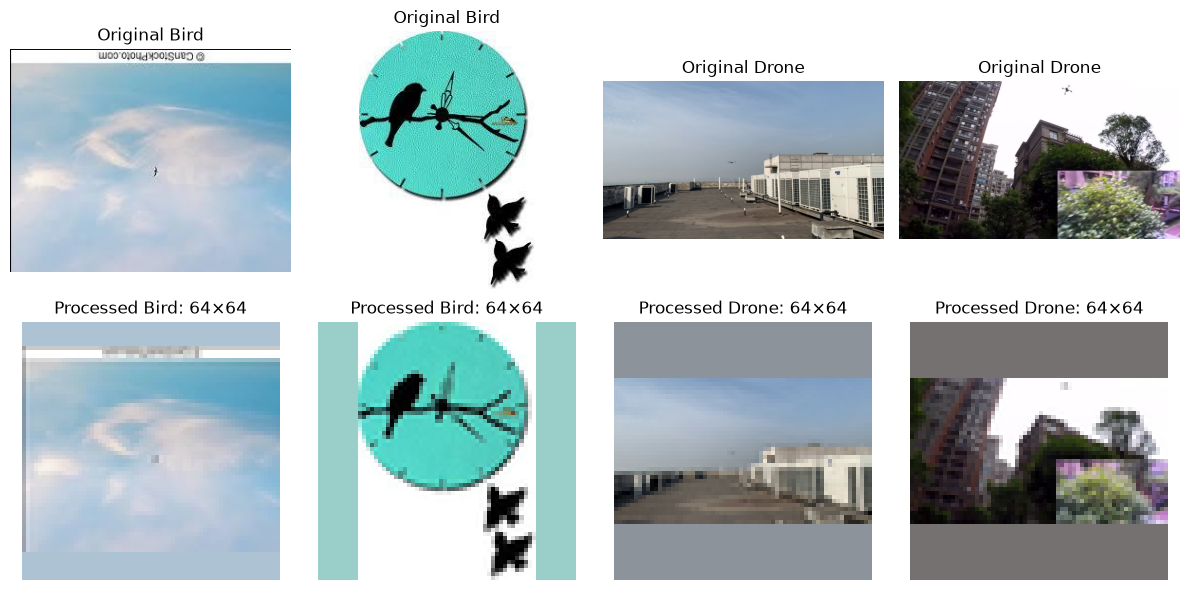

In [15]:
sample_rows = pd.concat([
    train_df[train_df["class"] == "Bird"].sample(
        2, random_state=42
    ),
    train_df[train_df["class"] == "Drone"].sample(
        2, random_state=42
    )
])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for column, (_, row) in enumerate(sample_rows.iterrows()):
    with Image.open(row["path"]) as original:
        axes[0, column].imshow(original.convert("RGB"))

    processed = preprocess_image(row["path"])
    axes[1, column].imshow(processed)

    axes[0, column].set_title(
        f'Original {row["class"]}'
    )
    axes[1, column].set_title(
        f'Processed {row["class"]}: 64×64'
    )

    axes[0, column].axis("off")
    axes[1, column].axis("off")

plt.tight_layout()
plt.show()

## 4. Feature Engineering

KNN cannot compare image files directly. Each image must be converted into a fixed-length numerical feature vector. We begin with a simple baseline representation: a 16×16 grayscale image, producing 256 normalized pixel features.

In [16]:
FEATURE_IMAGE_SIZE = (16, 16)

def extract_grayscale_features(image_path):
    processed_image = preprocess_image(image_path)

    grayscale_image = processed_image.convert("L")
    grayscale_image = grayscale_image.resize(
        FEATURE_IMAGE_SIZE,
        Image.Resampling.LANCZOS
    )

    grayscale_array = np.asarray(
        grayscale_image,
        dtype=np.float32
    ) / 255.0

    feature_vector = grayscale_array.flatten()

    return feature_vector

In [17]:
import time

def build_feature_matrix(dataframe):
    feature_vectors = []

    for image_path in dataframe["path"]:
        features = extract_grayscale_features(
            image_path
        )
        feature_vectors.append(features)

    X = np.vstack(feature_vectors)
    y = dataframe["label"].to_numpy()

    return X, y


start_time = time.time()

X_train_gray, y_train = build_feature_matrix(
    train_df
)

X_validation_gray, y_validation = build_feature_matrix(
    validation_df
)

X_test_gray, y_test = build_feature_matrix(
    test_df
)

elapsed_time = time.time() - start_time

print("Train:", X_train_gray.shape, y_train.shape)
print(
    "Validation:",
    X_validation_gray.shape,
    y_validation.shape
)
print("Test:", X_test_gray.shape, y_test.shape)
print(f"Processing time: {elapsed_time:.2f} seconds")

Train: (2289, 256) (2289,)
Validation: (626, 256) (626,)
Test: (777, 256) (777,)
Processing time: 55.23 seconds


## 5. Supervised Learning: KNN Classification

A manual KNN classifier is evaluated with four feature representations and several hyperparameter settings. Model selection uses five-fold group-aware cross-validation, while the held-out test set is reserved for the final evaluation.

In [18]:
def calculate_metrics(y_true, y_pred):
    true_positive = np.sum(
        (y_true == 1) & (y_pred == 1)
    )
    false_positive = np.sum(
        (y_true == 0) & (y_pred == 1)
    )
    false_negative = np.sum(
        (y_true == 1) & (y_pred == 0)
    )
    true_negative = np.sum(
        (y_true == 0) & (y_pred == 0)
    )

    accuracy = (
        (true_positive + true_negative) /
        len(y_true)
    )

    precision = (
        true_positive /
        (true_positive + false_positive)
        if true_positive + false_positive > 0
        else 0
    )

    recall = (
        true_positive /
        (true_positive + false_negative)
        if true_positive + false_negative > 0
        else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if precision + recall > 0
        else 0
    )

    return {
        "accuracy": accuracy,
        "precision_bird": precision,
        "recall_bird": recall,
        "f1_bird": f1
    }

In [19]:
baseline_predictions = np.zeros_like(
    y_validation
)

baseline_metrics = calculate_metrics(
    y_validation,
    baseline_predictions
)

baseline_metrics

{'accuracy': np.float64(0.6789137380191693),
 'precision_bird': 0,
 'recall_bird': np.float64(0.0),
 'f1_bird': 0}

### Majority-Class Baseline

A baseline model that always predicts the majority class, Drone, achieves approximately 67.9% validation accuracy. However, its bird precision, recall and F1-score are all zero because it does not identify any birds. Its zero Bird F1-score shows why accuracy is not sufficient as the only evaluation metric.

In [20]:
def calculate_distances(
    query_features,
    X_train,
    distance_metric="euclidean"
):
    differences = X_train - query_features

    if distance_metric == "euclidean":
        return np.sqrt(
            np.sum(differences ** 2, axis=1)
        )

    if distance_metric == "manhattan":
        return np.sum(
            np.abs(differences),
            axis=1
        )

    raise ValueError(
        "distance_metric must be 'euclidean' or 'manhattan'"
    )


def predict_one_knn(
    query_features,
    X_train,
    y_train,
    k=5,
    distance_metric="euclidean"
):
    distances = calculate_distances(
        query_features,
        X_train,
        distance_metric
    )

    nearest_indices = np.argsort(
        distances
    )[:k]

    nearest_labels = y_train[
        nearest_indices
    ]

    label_counts = np.bincount(
        nearest_labels,
        minlength=2
    )

    prediction = np.argmax(label_counts)

    return (
        prediction,
        nearest_indices,
        distances[nearest_indices]
    )

In [21]:
prediction, neighbor_indices, neighbor_distances = (
    predict_one_knn(
        X_validation_gray[0],
        X_train_gray,
        y_train,
        k=5
    )
)

print("True label:", y_validation[0])
print("Predicted label:", prediction)
print("Neighbor labels:", y_train[neighbor_indices])
print("Neighbor distances:", neighbor_distances)

True label: 1
Predicted label: 1
Neighbor labels: [1 1 1 0 1]
Neighbor distances: [1.1553063 1.3356439 1.3916873 1.3931286 1.3953513]


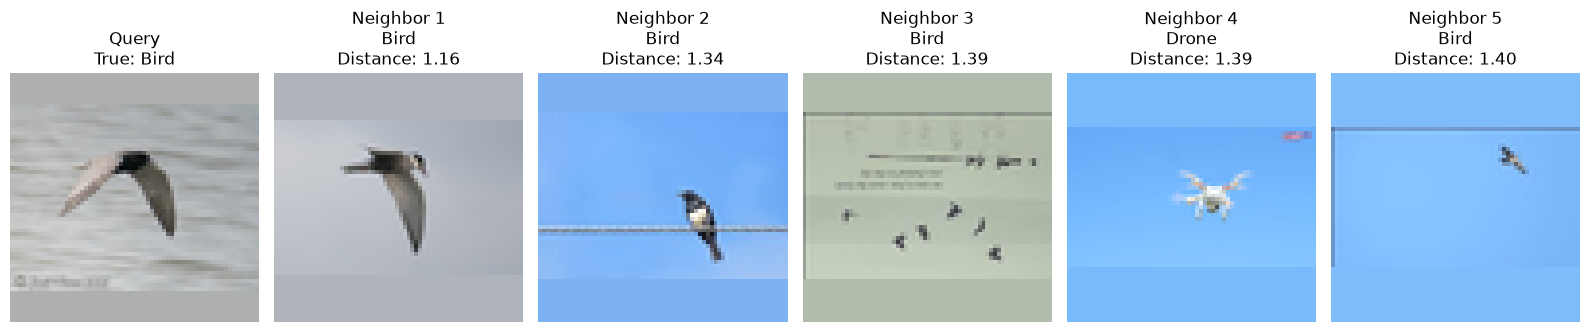

In [22]:
label_names = {
    0: "Drone",
    1: "Bird"
}

fig, axes = plt.subplots(
    1,
    6,
    figsize=(16, 4)
)

query_image = preprocess_image(
    validation_df.iloc[0]["path"]
)

axes[0].imshow(query_image)
axes[0].set_title(
    "Query\n"
    f'True: {label_names[y_validation[0]]}'
)
axes[0].axis("off")

for position, neighbor_index in enumerate(
    neighbor_indices,
    start=1
):
    neighbor_path = train_df.iloc[
        neighbor_index
    ]["path"]

    neighbor_image = preprocess_image(
        neighbor_path
    )

    neighbor_label = y_train[
        neighbor_index
    ]

    axes[position].imshow(neighbor_image)
    axes[position].set_title(
        f"Neighbor {position}\n"
        f"{label_names[neighbor_label]}\n"
        f"Distance: "
        f"{neighbor_distances[position - 1]:.2f}"
    )
    axes[position].axis("off")

plt.tight_layout()
plt.show()

### Nearest-Neighbor Inspection

The closest neighbor is visually similar to the query bird, but several other neighbors appear similar mainly because of their background color and object position. One of the five closest neighbors is a drone with a similar sky background. The nearest neighbors show that grayscale pixels capture background brightness and object position in addition to shape.

In [23]:
def predict_dataset_knn(
    X_query,
    X_train,
    y_train,
    k=5,
    distance_metric="euclidean"
):
    predictions = []

    for index, query_features in enumerate(
        X_query
    ):
        prediction, _, _ = predict_one_knn(
            query_features,
            X_train,
            y_train,
            k,
            distance_metric=distance_metric
        )

        predictions.append(prediction)

        if (index + 1) % 100 == 0:
            print(
                f"Processed {index + 1} "
                f"of {len(X_query)} images"
            )

    return np.asarray(predictions)

In [24]:
COLOR_BINS = 16

def extract_color_features(image_path):
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image)
        image = image.convert("RGB")
        image = image.resize(
            IMAGE_SIZE,
            Image.Resampling.LANCZOS
        )
        hsv_image = image.convert("HSV")

    hsv_array = np.asarray(hsv_image)

    histograms = []

    for channel in range(3):
        histogram, _ = np.histogram(
            hsv_array[:, :, channel],
            bins=COLOR_BINS,
            range=(0, 256)
        )

        histogram = histogram.astype(
            np.float32
        )

        histogram = (
            histogram / histogram.sum()
        )

        histograms.append(histogram)

    return np.concatenate(histograms)

In [25]:
def build_color_feature_matrix(dataframe):
    feature_vectors = []

    for index, image_path in enumerate(
        dataframe["path"]
    ):
        features = extract_color_features(
            image_path
        )

        feature_vectors.append(features)

        if (index + 1) % 500 == 0:
            print(
                f"Processed {index + 1} "
                f"of {len(dataframe)} images"
            )

    X = np.vstack(feature_vectors)
    y = dataframe["label"].to_numpy()

    return X, y

In [26]:
start_time = time.time()

X_train_color, _ = build_color_feature_matrix(
    train_df
)

X_validation_color, _ = build_color_feature_matrix(
    validation_df
)

X_test_color, _ = build_color_feature_matrix(
    test_df
)

print("Train color:", X_train_color.shape)
print(
    "Validation color:",
    X_validation_color.shape
)
print("Test color:", X_test_color.shape)

print(
    f"Processing time: "
    f"{time.time() - start_time:.2f} seconds"
)

Processed 500 of 2289 images
Processed 1000 of 2289 images
Processed 1500 of 2289 images
Processed 2000 of 2289 images
Processed 500 of 626 images
Processed 500 of 777 images
Train color: (2289, 48)
Validation color: (626, 48)
Test color: (777, 48)
Processing time: 102.58 seconds


In [27]:
EDGE_IMAGE_SIZE = (16, 16)


def extract_edge_features(image_path):
    processed_image = preprocess_image(
        image_path
    )

    grayscale_image = (
        processed_image
        .convert("L")
        .resize(
            EDGE_IMAGE_SIZE,
            Image.Resampling.LANCZOS
        )
    )

    grayscale_array = (
        np.asarray(
            grayscale_image,
            dtype=np.float32
        ) / 255.0
    )

    vertical_gradient, horizontal_gradient = (
        np.gradient(grayscale_array)
    )

    edge_magnitude = np.sqrt(
        horizontal_gradient ** 2
        + vertical_gradient ** 2
    )

    return edge_magnitude.flatten()

### Feature Engineering Examples from Train and Test

The examples below show how fixed training and test images are converted into feature vectors. One Bird and one Drone were selected from each set using a fixed random seed, independently of the model's predictions.

For every image, we display the processed RGB image, the 16×16 grayscale
representation, the normalized HSV color histograms and the edge-magnitude
representation. The same feature-engineering functions are applied to both
training and test images.

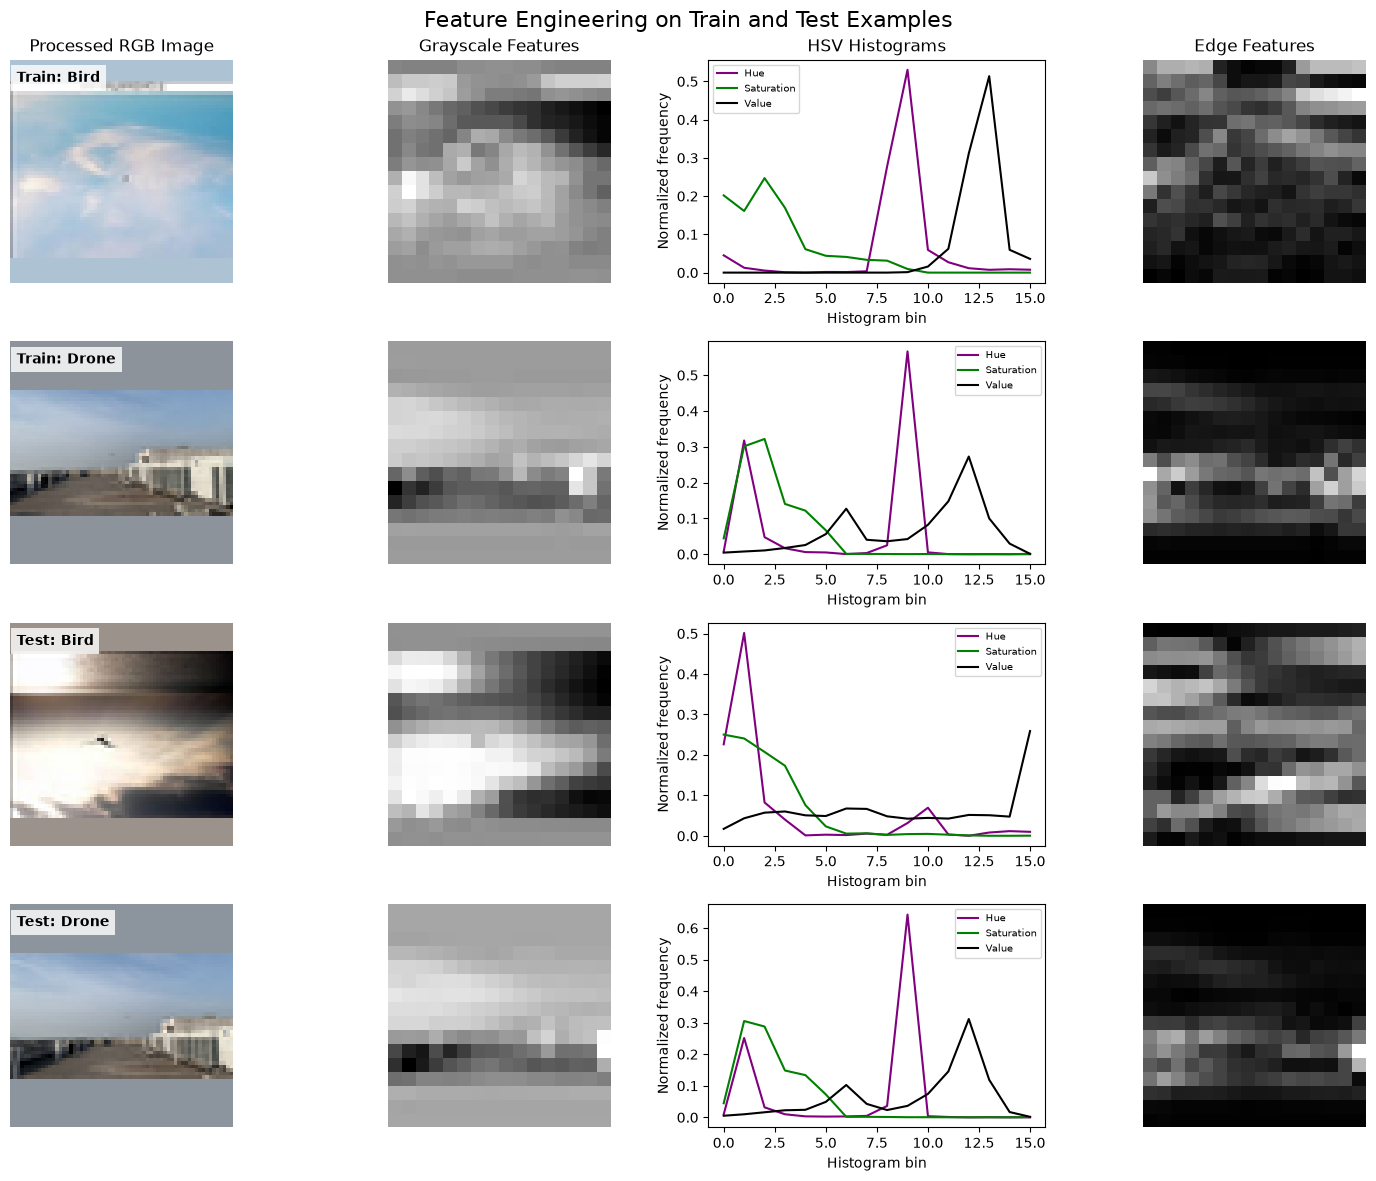

In [28]:
def select_feature_examples(dataframe, split_name):
    selected_examples = pd.concat([
        dataframe[
            dataframe["class"] == "Bird"
        ].sample(1, random_state=42),

        dataframe[
            dataframe["class"] == "Drone"
        ].sample(1, random_state=42)
    ])

    return selected_examples.assign(
        dataset_split=split_name
    )


feature_examples = pd.concat([
    select_feature_examples(train_df, "Train"),
    select_feature_examples(test_df, "Test")
]).reset_index(drop=True)


figure, axes = plt.subplots(
    len(feature_examples),
    4,
    figsize=(15, 12)
)

histogram_colors = [
    "purple",
    "green",
    "black"
]

histogram_labels = [
    "Hue",
    "Saturation",
    "Value"
]


for row_number, example in feature_examples.iterrows():
    processed_image = preprocess_image(
        example["path"]
    )

    grayscale_features = (
        extract_grayscale_features(
            example["path"]
        ).reshape(16, 16)
    )

    color_features = (
        extract_color_features(
            example["path"]
        ).reshape(3, COLOR_BINS)
    )

    edge_features = (
        extract_edge_features(
            example["path"]
        ).reshape(16, 16)
    )

    axes[row_number, 0].imshow(
        processed_image
    )

    axes[row_number, 0].text(
        0.03,
        0.95,
        f'{example["dataset_split"]}: '
        f'{example["class"]}',
        transform=axes[row_number, 0].transAxes,
        ha="left",
        va="top",
        fontsize=10,
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "alpha": 0.8,
            "edgecolor": "none"
        }
    )

    axes[row_number, 1].imshow(
        grayscale_features,
        cmap="gray"
    )

    for channel_number in range(3):
        axes[row_number, 2].plot(
            range(COLOR_BINS),
            color_features[channel_number],
            color=histogram_colors[channel_number],
            label=histogram_labels[channel_number]
        )

    axes[row_number, 2].set_xlabel(
        "Histogram bin"
    )

    axes[row_number, 2].set_ylabel(
        "Normalized frequency"
    )

    axes[row_number, 2].legend(
        fontsize=7
    )

    axes[row_number, 3].imshow(
        edge_features,
        cmap="gray"
    )

    axes[row_number, 0].axis("off")
    axes[row_number, 1].axis("off")
    axes[row_number, 3].axis("off")


column_titles = [
    "Processed RGB Image",
    "Grayscale Features",
    "HSV Histograms",
    "Edge Features"
]

for column_number, title in enumerate(
    column_titles
):
    axes[0, column_number].set_title(
        title,
        fontsize=12
    )


plt.suptitle(
    "Feature Engineering on Train and Test Examples",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [29]:
def build_edge_feature_matrix(dataframe):
    feature_vectors = []

    for index, image_path in enumerate(
        dataframe["path"]
    ):
        features = extract_edge_features(
            image_path
        )

        feature_vectors.append(features)

        if (index + 1) % 500 == 0:
            print(
                f"Processed {index + 1} "
                f"of {len(dataframe)} images"
            )

    X = np.vstack(feature_vectors)
    y = dataframe["label"].to_numpy()

    return X, y

In [30]:
start_time = time.time()

X_train_edges, _ = build_edge_feature_matrix(
    train_df
)

X_validation_edges, _ = build_edge_feature_matrix(
    validation_df
)

X_test_edges, _ = build_edge_feature_matrix(
    test_df
)

print("Train edges:", X_train_edges.shape)
print(
    "Validation edges:",
    X_validation_edges.shape
)
print("Test edges:", X_test_edges.shape)

print(
    f"Processing time: "
    f"{time.time() - start_time:.2f} seconds"
)

Processed 500 of 2289 images
Processed 1000 of 2289 images
Processed 1500 of 2289 images
Processed 2000 of 2289 images
Processed 500 of 626 images
Processed 500 of 777 images
Train edges: (2289, 256)
Validation edges: (626, 256)
Test edges: (777, 256)
Processing time: 55.19 seconds


In [31]:
def predict_one_weighted_knn(
    query_features,
    X_train,
    y_train,
    k=5,
    distance_metric="euclidean"
):
    distances = calculate_distances(
        query_features,
        X_train,
        distance_metric
    )
    nearest_indices = np.argsort(
        distances
    )[:k]

    nearest_distances = distances[
        nearest_indices
    ]

    nearest_labels = y_train[
        nearest_indices
    ]

    weights = 1 / (
        nearest_distances + 1e-8
    )

    weighted_votes = np.bincount(
        nearest_labels,
        weights=weights,
        minlength=2
    )

    return np.argmax(weighted_votes)

In [32]:
def predict_dataset_weighted_knn(
    X_query,
    X_train,
    y_train,
    k,
    distance_metric="euclidean"
):
    predictions = []

    for query_features in X_query:
        prediction = predict_one_weighted_knn(
            query_features,
            X_train,
            y_train,
            k,
            distance_metric=distance_metric
        )

        predictions.append(prediction)

    return np.asarray(predictions)

### KNN Training and Prediction Interface

KNN is a lazy-learning algorithm. Unlike linear regression or a decision
tree, it does not estimate coefficients or construct a tree during training.
Therefore, the `fit` operation validates and stores the training feature
vectors and their labels.

During `predict`, every query vector is compared with the stored training
vectors using the selected distance metric: Euclidean or Manhattan. The `k`
closest neighbors are selected, and the prediction is determined using either
uniform majority voting or distance-weighted voting. Therefore, `k`, the
voting method and the distance metric are hyperparameters of the model.

In [33]:
class ManualKNNClassifier:
    def __init__(
        self,
        k=5,
        voting="uniform",
        distance_metric="euclidean"
    ):
        if k < 1:
            raise ValueError(
                "k must be at least 1."
            )

        if voting not in {
            "uniform",
            "weighted"
        }:
            raise ValueError(
                "voting must be "
                "'uniform' or 'weighted'."
            )

        if distance_metric not in {
            "euclidean",
            "manhattan"
        }:
            raise ValueError(
                "distance_metric must be "
                "'euclidean' or 'manhattan'."
            )

        self.k = k
        self.voting = voting
        self.distance_metric = distance_metric
        self.is_fitted = False

    def fit(self, X_train, y_train):
        X_train = np.asarray(
            X_train,
            dtype=np.float32
        )

        y_train = np.asarray(
            y_train,
            dtype=int
        )

        if X_train.ndim != 2:
            raise ValueError(
                "X_train must be "
                "a two-dimensional matrix."
            )

        if len(X_train) != len(y_train):
            raise ValueError(
                "X_train and y_train must "
                "contain the same number "
                "of examples."
            )

        if self.k > len(X_train):
            raise ValueError(
                "k cannot be larger than "
                "the training set."
            )

        self.X_train = X_train.copy()
        self.y_train = y_train.copy()
        self.is_fitted = True

        return self


    def predict(self, X_query):
        if not self.is_fitted:
            raise RuntimeError(
                "The model must be fitted "
                "before prediction."
            )

        X_query = np.asarray(
            X_query,
            dtype=np.float32
        )

        if X_query.ndim != 2:
            raise ValueError(
                "X_query must be "
                "a two-dimensional matrix."
            )

        predictions = []

        for query_features in X_query:
            if self.voting == "weighted":
                prediction = predict_one_weighted_knn(
                    query_features,
                    self.X_train,
                    self.y_train,
                    self.k,
                    distance_metric=self.distance_metric
                )
            else:
                prediction, _, _ = predict_one_knn(
                    query_features,
                    self.X_train,
                    self.y_train,
                    self.k,
                    distance_metric=self.distance_metric
                )

            predictions.append(prediction)

        return np.asarray(predictions)

### Five-Fold Cross-Validation Grid Search

The training and validation subsets were combined into a development set. Five-fold group-aware cross-validation kept each source group within one fold. The grid tested four feature representations, five values of k, two voting methods and two distance metrics, resulting in 80 configurations and 400 evaluations.

Feature scaling was fitted only on the training portion of each fold. The test set remained separate until the final evaluation.

In [34]:
development_cv_df = pd.concat(
    [
        train_df,
        validation_df
    ],
    ignore_index=True
)

development_feature_matrices = {
    "grayscale": np.vstack([
        X_train_gray,
        X_validation_gray
    ]),
    "hsv": np.vstack([
        X_train_color,
        X_validation_color
    ]),
    "edges": np.vstack([
        X_train_edges,
        X_validation_edges
    ])
}

y_development_cv = np.concatenate([
    y_train,
    y_validation
])


def assign_group_cv_folds(
    dataframe,
    n_splits=5,
    seed=42
):
    random_generator = np.random.default_rng(seed)
    group_to_fold = {}

    for class_name in ["Bird", "Drone"]:
        class_data = dataframe[
            dataframe["class"] == class_name
        ]

        group_sizes = (
            class_data.groupby("source_group")
            .size()
        )

        groups = group_sizes.index.to_list()
        random_generator.shuffle(groups)

        groups = sorted(
            groups,
            key=lambda group: group_sizes[group],
            reverse=True
        )

        fold_sizes = np.zeros(
            n_splits,
            dtype=int
        )

        for group in groups:
            smallest_fold = int(
                np.argmin(fold_sizes)
            )

            group_to_fold[group] = smallest_fold
            fold_sizes[smallest_fold] += int(
                group_sizes[group]
            )

    return (
        dataframe["source_group"]
        .map(group_to_fold)
        .to_numpy()
    )


development_cv_df["cv_fold"] = (
    assign_group_cv_folds(
        development_cv_df,
        n_splits=5,
        seed=42
    )
)

fold_summary = pd.crosstab(
    development_cv_df["cv_fold"],
    development_cv_df["class"],
    margins=True
)

display(fold_summary)

groups_per_fold = (
    development_cv_df
    .groupby("source_group")["cv_fold"]
    .nunique()
)

assert groups_per_fold.max() == 1

for feature_name, feature_matrix in (
    development_feature_matrices.items()
):
    print(
        f"{feature_name} development features:",
        feature_matrix.shape
    )

print(
    "Groups appearing in multiple folds:",
    (groups_per_fold > 1).sum()
)

class,Bird,Drone,All
cv_fold,,,
0,201,383,584
1,200,383,583
2,200,383,583
3,200,383,583
4,200,382,582
All,1001,1914,2915


grayscale development features: (2915, 256)
hsv development features: (2915, 48)
edges development features: (2915, 256)
Groups appearing in multiple folds: 0


In [35]:
def standardize_train_and_query(
    X_training,
    X_query
):
    training_mean = X_training.mean(axis=0)
    training_std = X_training.std(axis=0)

    training_std[
        training_std < 1e-8
    ] = 1.0

    X_training_scaled = (
        (X_training - training_mean) /
        training_std
    )

    X_query_scaled = (
        (X_query - training_mean) /
        training_std
    )

    return X_training_scaled, X_query_scaled


def prepare_cv_features(
    feature_name,
    training_mask,
    validation_mask
):
    if feature_name != "combined":
        feature_matrix = (
            development_feature_matrices[
                feature_name
            ]
        )

        return (
            feature_matrix[training_mask],
            feature_matrix[validation_mask]
        )

    color_matrix = (
        development_feature_matrices["hsv"]
    )
    edge_matrix = (
        development_feature_matrices["edges"]
    )

    (
        color_training,
        color_validation
    ) = standardize_train_and_query(
        color_matrix[training_mask],
        color_matrix[validation_mask]
    )

    (
        edge_training,
        edge_validation
    ) = standardize_train_and_query(
        edge_matrix[training_mask],
        edge_matrix[validation_mask]
    )

    color_weight = np.sqrt(
        color_training.shape[1]
    )
    edge_weight = np.sqrt(
        edge_training.shape[1]
    )

    combined_training = np.hstack([
        color_training / color_weight,
        edge_training / edge_weight
    ])

    combined_validation = np.hstack([
        color_validation / color_weight,
        edge_validation / edge_weight
    ])

    return (
        combined_training,
        combined_validation
    )

In [36]:
def predict_multiple_knn_configurations(
    X_query,
    X_training,
    y_training,
    k_values,
    distance_metric
):
    predictions = {
        (k, voting): []
        for k in k_values
        for voting in ["uniform", "weighted"]
    }

    maximum_k = max(k_values)

    for query_features in X_query:
        distances = calculate_distances(
            query_features,
            X_training,
            distance_metric
        )

        nearest_indices = np.argsort(
            distances
        )[:maximum_k]

        nearest_labels = y_training[
            nearest_indices
        ]

        nearest_distances = distances[
            nearest_indices
        ]

        for k in k_values:
            current_labels = nearest_labels[:k]
            current_distances = (
                nearest_distances[:k]
            )

            uniform_votes = np.bincount(
                current_labels,
                minlength=2
            )

            uniform_prediction = np.argmax(
                uniform_votes
            )

            weights = 1 / (
                current_distances + 1e-8
            )

            weighted_votes = np.bincount(
                current_labels,
                weights=weights,
                minlength=2
            )

            weighted_prediction = np.argmax(
                weighted_votes
            )

            predictions[
                (k, "uniform")
            ].append(uniform_prediction)

            predictions[
                (k, "weighted")
            ].append(weighted_prediction)

    return {
        configuration: np.asarray(values)
        for configuration, values
        in predictions.items()
    }

In [37]:
grid_feature_names = [
    "grayscale",
    "hsv",
    "edges",
    "combined"
]

grid_k_values = [1, 3, 5, 7, 11]

grid_voting_methods = [
    "uniform",
    "weighted"
]

grid_distance_metrics = [
    "euclidean",
    "manhattan"
]

cv_fold_assignments = (
    development_cv_df["cv_fold"]
    .to_numpy()
)

fold_metrics_by_configuration = {
    (
        feature_name,
        k,
        voting,
        distance_metric
    ): []
    for feature_name in grid_feature_names
    for k in grid_k_values
    for voting in grid_voting_methods
    for distance_metric in grid_distance_metrics
}


for feature_name in grid_feature_names:
    for fold in range(5):
        cv_validation_mask = (
            cv_fold_assignments == fold
        )

        cv_training_mask = (
            cv_fold_assignments != fold
        )

        (
            X_cv_training,
            X_cv_validation
        ) = prepare_cv_features(
            feature_name,
            cv_training_mask,
            cv_validation_mask
        )

        y_cv_training = y_development_cv[
            cv_training_mask
        ]

        y_cv_validation = y_development_cv[
            cv_validation_mask
        ]

        for distance_metric in (
            grid_distance_metrics
        ):
            predictions_by_configuration = (
                predict_multiple_knn_configurations(
                    X_cv_validation,
                    X_cv_training,
                    y_cv_training,
                    grid_k_values,
                    distance_metric
                )
            )

            for k in grid_k_values:
                for voting in (
                    grid_voting_methods
                ):
                    predictions = (
                        predictions_by_configuration[
                            (k, voting)
                        ]
                    )

                    metrics = calculate_metrics(
                        y_cv_validation,
                        predictions
                    )

                    configuration = (
                        feature_name,
                        k,
                        voting,
                        distance_metric
                    )

                    fold_metrics_by_configuration[
                        configuration
                    ].append(metrics)

        print(
            "Completed:",
            f"feature={feature_name},",
            f"fold={fold + 1}"
        )


grid_search_results = []

for configuration, fold_metrics in (
    fold_metrics_by_configuration.items()
):
    (
        feature_name,
        k,
        voting,
        distance_metric
    ) = configuration

    grid_search_results.append({
        "feature_type": feature_name,
        "k": k,
        "voting": voting,
        "distance_metric": distance_metric,
        "mean_accuracy": np.mean([
            result["accuracy"]
            for result in fold_metrics
        ]),
        "mean_precision_bird": np.mean([
            result["precision_bird"]
            for result in fold_metrics
        ]),
        "mean_recall_bird": np.mean([
            result["recall_bird"]
            for result in fold_metrics
        ]),
        "mean_f1_bird": np.mean([
            result["f1_bird"]
            for result in fold_metrics
        ]),
        "std_f1_bird": np.std([
            result["f1_bird"]
            for result in fold_metrics
        ])
    })


grid_search_results_df = pd.DataFrame(
    grid_search_results
).sort_values(
    [
        "mean_f1_bird",
        "mean_accuracy"
    ],
    ascending=False
).reset_index(drop=True)

assert len(grid_search_results_df) == 80

print(
    "Number of grid configurations:",
    len(grid_search_results_df)
)

print(
    "Number of model evaluations:",
    len(grid_search_results_df) * 5
)

print("Complete Grid Search Results:")

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None
):
    display(
        grid_search_results_df.round(4)
    )

print("Best Configuration:")

display(
    grid_search_results_df
    .head(1)
    .round(4)
)

Completed: feature=grayscale, fold=1
Completed: feature=grayscale, fold=2
Completed: feature=grayscale, fold=3
Completed: feature=grayscale, fold=4
Completed: feature=grayscale, fold=5
Completed: feature=hsv, fold=1
Completed: feature=hsv, fold=2
Completed: feature=hsv, fold=3
Completed: feature=hsv, fold=4
Completed: feature=hsv, fold=5
Completed: feature=edges, fold=1
Completed: feature=edges, fold=2
Completed: feature=edges, fold=3
Completed: feature=edges, fold=4
Completed: feature=edges, fold=5
Completed: feature=combined, fold=1
Completed: feature=combined, fold=2
Completed: feature=combined, fold=3
Completed: feature=combined, fold=4
Completed: feature=combined, fold=5
Number of grid configurations: 80
Number of model evaluations: 400
Complete Grid Search Results:


,feature_type,k,voting,distance_metric,mean_accuracy,mean_precision_bird,mean_recall_bird,mean_f1_bird,std_f1_bird
0,combined,1,uniform,manhattan,0.9033,0.8793,0.8382,0.8568,0.0282
1,combined,1,weighted,manhattan,0.9033,0.8793,0.8382,0.8568,0.0282
2,combined,3,uniform,manhattan,0.8961,0.8711,0.8292,0.8468,0.0269
3,combined,3,weighted,manhattan,0.8961,0.8711,0.8292,0.8468,0.0269
4,combined,7,weighted,manhattan,0.8919,0.8926,0.7872,0.8344,0.0253
5,combined,5,weighted,manhattan,0.8878,0.8702,0.8032,0.8327,0.0349
6,combined,7,uniform,manhattan,0.8902,0.8897,0.7862,0.8322,0.0280
7,combined,5,uniform,manhattan,0.8871,0.8698,0.8022,0.8319,0.0376
8,combined,1,uniform,euclidean,0.8782,0.8363,0.8062,0.8199,0.0420
9,combined,1,weighted,euclidean,0.8782,0.8363,0.8062,0.8199,0.0420


Best Configuration:


,feature_type,k,voting,distance_metric,mean_accuracy,mean_precision_bird,mean_recall_bird,mean_f1_bird,std_f1_bird
0,combined,1,uniform,manhattan,0.9033,0.8793,0.8382,0.8568,0.0282


### Grid Search Results

The best configuration used combined HSV-and-edge features, k=1, uniform
voting and Manhattan distance. It achieved a mean cross-validation accuracy
of 0.9033 and a mean bird F1-score of 0.8568, with an F1 standard deviation
of 0.0282.

Uniform and distance-weighted voting produced identical results for k=1 because the prediction is determined by only one neighbor. Because weighting has no effect when k=1, uniform voting was selected as the simpler option. The held-out test set remained excluded from this decision.

In [38]:
best_cv_configuration = (
    grid_search_results_df.iloc[0]
)

best_feature_type = (
    best_cv_configuration["feature_type"]
)

best_k = int(
    best_cv_configuration["k"]
)

best_voting = (
    best_cv_configuration["voting"]
)

best_distance_metric = (
    best_cv_configuration["distance_metric"]
)

print("Best k:", best_k)
print(
    "Best feature type:",
    best_feature_type
)
print("Best voting method:", best_voting)
print(
    "Best distance metric:",
    best_distance_metric
)

Best k: 1
Best feature type: combined
Best voting method: uniform
Best distance metric: manhattan


### Class-Imbalance Adaptation

The development data contain more Drone images than Bird images. Random
undersampling was evaluated as a class-balancing adaptation. Within each
cross-validation fold, Drone examples were randomly reduced to match the
number of Bird examples.

Undersampling was applied only to the training portion of each fold. The
validation folds and held-out test set retained their original class
distribution. The original and undersampled models were compared using the
Bird F1-score.

In [39]:
def random_undersample_training(
    X_training,
    y_training,
    seed
):
    random_generator = np.random.default_rng(
        seed
    )

    bird_indices = np.where(
        y_training == 1
    )[0]

    drone_indices = np.where(
        y_training == 0
    )[0]

    balanced_class_size = min(
        len(bird_indices),
        len(drone_indices)
    )

    selected_bird_indices = (
        random_generator.choice(
            bird_indices,
            size=balanced_class_size,
            replace=False
        )
    )

    selected_drone_indices = (
        random_generator.choice(
            drone_indices,
            size=balanced_class_size,
            replace=False
        )
    )

    selected_indices = np.concatenate([
        selected_bird_indices,
        selected_drone_indices
    ])

    random_generator.shuffle(
        selected_indices
    )

    return (
        X_training[selected_indices],
        y_training[selected_indices],
        selected_indices
    )

In [40]:
balancing_strategies = [
    "none",
    "random_undersampling"
]

balancing_results = []

for balancing_strategy in balancing_strategies:
    fold_metrics = []
    fold_training_sizes = []

    for fold in range(5):
        cv_validation_mask = (
            cv_fold_assignments == fold
        )

        cv_training_mask = (
            cv_fold_assignments != fold
        )

        (
            X_cv_training,
            X_cv_validation
        ) = prepare_cv_features(
            best_feature_type,
            cv_training_mask,
            cv_validation_mask
        )

        y_cv_training = y_development_cv[
            cv_training_mask
        ]

        y_cv_validation = y_development_cv[
            cv_validation_mask
        ]

        if (
            balancing_strategy ==
            "random_undersampling"
        ):
            (
                X_cv_training,
                y_cv_training,
                _
            ) = random_undersample_training(
                X_cv_training,
                y_cv_training,
                seed=42 + fold
            )

        fold_training_sizes.append(
            len(y_cv_training)
        )

        balancing_model = ManualKNNClassifier(
            k=best_k,
            voting=best_voting,
            distance_metric=best_distance_metric
        )

        balancing_model.fit(
            X_cv_training,
            y_cv_training
        )

        balancing_predictions = (
            balancing_model.predict(
                X_cv_validation
            )
        )

        metrics = calculate_metrics(
            y_cv_validation,
            balancing_predictions
        )

        fold_metrics.append(metrics)

    balancing_results.append({
        "balancing_strategy": (
            balancing_strategy
        ),
        "mean_training_size": np.mean(
            fold_training_sizes
        ),
        "mean_accuracy": np.mean([
            result["accuracy"]
            for result in fold_metrics
        ]),
        "mean_precision_bird": np.mean([
            result["precision_bird"]
            for result in fold_metrics
        ]),
        "mean_recall_bird": np.mean([
            result["recall_bird"]
            for result in fold_metrics
        ]),
        "mean_f1_bird": np.mean([
            result["f1_bird"]
            for result in fold_metrics
        ]),
        "std_f1_bird": np.std([
            result["f1_bird"]
            for result in fold_metrics
        ])
    })

    print(
        "Completed:",
        balancing_strategy
    )


balancing_results_df = pd.DataFrame(
    balancing_results
).sort_values(
    [
        "mean_f1_bird",
        "mean_accuracy"
    ],
    ascending=False
).reset_index(drop=True)

display(
    balancing_results_df.round(4)
)

best_balancing_strategy = (
    balancing_results_df.iloc[0][
        "balancing_strategy"
    ]
)

print(
    "Best balancing strategy:",
    best_balancing_strategy
)

Completed: none
Completed: random_undersampling


,balancing_strategy,mean_training_size,mean_accuracy,mean_precision_bird,mean_recall_bird,mean_f1_bird,std_f1_bird
0,random_undersampling,1601.6,0.9005,0.8499,0.8711,0.8587,0.0308
1,none,2332.0,0.9033,0.8793,0.8382,0.8568,0.0282


Best balancing strategy: random_undersampling


### Class-Imbalance Results

Random undersampling reduced the average cross-validation training size from 2,332.0 to 1,601.6 examples. It increased mean Bird recall from 0.8382 to 0.8711, while mean Bird F1-score increased slightly from 0.8568 to 0.8587. Mean accuracy decreased from 0.9033 to 0.9005.

The F1 improvement was small relative to the variation between folds, so the experiment does not provide strong evidence that undersampling is generally superior. Nevertheless, random undersampling was selected because Bird F1-score was defined in advance as the primary evaluation metric, and the held-out test set was not used in this decision.

In [41]:
test_feature_matrices = {
    "grayscale": X_test_gray,
    "hsv": X_test_color,
    "edges": X_test_edges
}


def prepare_final_features(feature_name):
    if feature_name != "combined":
        return (
            development_feature_matrices[
                feature_name
            ],
            test_feature_matrices[
                feature_name
            ]
        )

    development_color = (
        development_feature_matrices["hsv"]
    )

    development_edges = (
        development_feature_matrices["edges"]
    )

    (
        development_color_scaled,
        test_color_scaled
    ) = standardize_train_and_query(
        development_color,
        X_test_color
    )

    (
        development_edges_scaled,
        test_edges_scaled
    ) = standardize_train_and_query(
        development_edges,
        X_test_edges
    )

    color_weight = np.sqrt(
        development_color_scaled.shape[1]
    )

    edge_weight = np.sqrt(
        development_edges_scaled.shape[1]
    )

    X_development_final = np.hstack([
        development_color_scaled / color_weight,
        development_edges_scaled / edge_weight
    ])

    X_test_final = np.hstack([
        test_color_scaled / color_weight,
        test_edges_scaled / edge_weight
    ])

    return (
        X_development_final,
        X_test_final
    )


(
    X_development_final,
    X_test_final
) = prepare_final_features(
    best_feature_type
)

y_development = np.concatenate([
    y_train,
    y_validation
])

if (
    best_balancing_strategy ==
    "random_undersampling"
):
    (
        X_final_training,
        y_final_training,
        final_training_indices
    ) = random_undersample_training(
        X_development_final,
        y_development,
        seed=42
    )
else:
    X_final_training = X_development_final
    y_final_training = y_development
    final_training_indices = np.arange(
    len(y_development)
)

final_training_df = (
    development_cv_df.iloc[
        final_training_indices
    ].reset_index(drop=True)
)

print(
    "Selected feature type:",
    best_feature_type
)

print(
    "Selected balancing strategy:",
    best_balancing_strategy
)

print(
    "Development set:",
    X_development_final.shape,
    y_development.shape
)

print(
    "Test feature matrix:",
    X_test_final.shape
)

final_knn_model = ManualKNNClassifier(
    k=best_k,
    voting=best_voting,
    distance_metric=best_distance_metric
)

final_knn_model.fit(
    X_final_training,
    y_final_training
)

print(
    "Final KNN model fitted with:",
    len(final_knn_model.X_train),
    "training examples"
)

Selected feature type: combined
Selected balancing strategy: random_undersampling
Development set: (2915, 304) (2915,)
Test feature matrix: (777, 304)
Final KNN model fitted with: 2002 training examples


In [42]:
start_time = time.time()

final_test_predictions = (
    final_knn_model.predict(
        X_test_final
    )
)

final_test_metrics = calculate_metrics(
    y_test,
    final_test_predictions
)

print(
    f"Final test prediction time: "
    f"{time.time() - start_time:.2f} seconds"
)

final_test_metrics

Final test prediction time: 0.40 seconds


{'accuracy': np.float64(0.9034749034749034),
 'precision_bird': np.float64(0.8345864661654135),
 'recall_bird': np.float64(0.8774703557312253),
 'f1_bird': np.float64(0.8554913294797688)}

In [43]:
for metric_name, metric_value in final_test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

accuracy: 0.9035
precision_bird: 0.8346
recall_bird: 0.8775
f1_bird: 0.8555


### First Five Test Predictions

The following table shows the model's predictions for the first five held-out test images. The true class is included for comparison.

In [44]:
first_five_predictions_df = pd.DataFrame({
    "image_name": (
        test_df.head(5)["path"]
        .map(lambda image_path: image_path.name)
        .to_numpy()
    ),
    "true_class": (
        test_df.head(5)["class"]
        .to_numpy()
    ),
    "predicted_class": np.where(
        final_test_predictions[:5] == 1,
        "Bird",
        "Drone"
    )
})

first_five_predictions_df["correct"] = (
    first_five_predictions_df["true_class"] ==
    first_five_predictions_df["predicted_class"]
)

first_five_predictions_df

,image_name,true_class,predicted_class,correct
0,105.jpg,Bird,Bird,True
1,121.jpg,Bird,Bird,True
2,139.jpg,Bird,Bird,True
3,143.jpg,Bird,Drone,False
4,146.jpg,Bird,Bird,True


The first five test rows happen to contain only Bird images. The model
correctly classified four of them and misclassified one as Drone. These five
rows demonstrate the prediction output and are not representative of the
complete test set. The final metrics and confusion matrix were calculated
using all 777 test images.

### Final Test Results

The final KNN model used combined HSV-and-edge features, random
undersampling, k=1, uniform voting and Manhattan distance. After
undersampling, the final training data contained 1,001 Bird and 1,001 Drone
examples, for a total of 2,002 training examples.

The model achieved an accuracy of 0.9035 and a Bird F1-score of 0.8555 on
the held-out test set. Bird precision was 0.8346 and recall was 0.8775.

This result is consistent with the undersampled five-fold cross-validation
mean Bird F1-score of 0.8587 and its standard deviation of 0.0308. The test
set was used only once for the final evaluation.

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_confusion_matrix = confusion_matrix(
    y_test,
    final_test_predictions,
    labels=[0, 1]
)

print(test_confusion_matrix)

[[480  44]
 [ 31 222]]


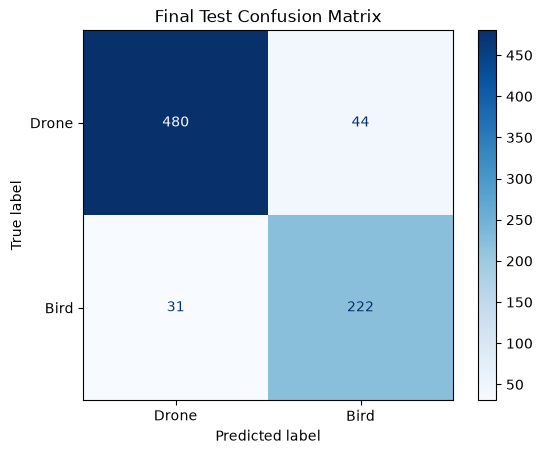

In [47]:
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=["Drone", "Bird"]
)

confusion_display.plot(cmap="Blues", values_format="d")
plt.title("Final Test Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The model correctly classified 480 of 524 drones (91.6%) and 222 of
253 birds (87.7%). It misclassified 44 drones as birds and 31 birds as
drones.

The selected model achieved relatively high recall for the minority Bird class, reflecting the model-selection emphasis on Bird F1-score and recall. Because no non-undersampled model was evaluated on the test set, these results cannot measure the isolated effect of undersampling.

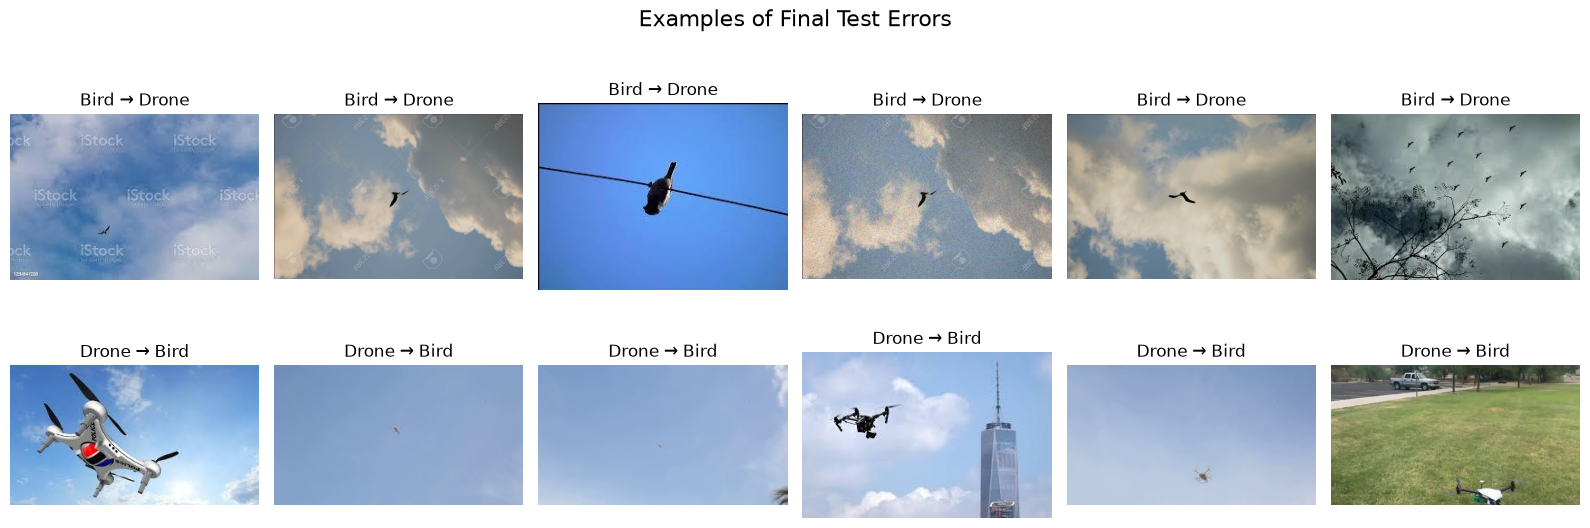

In [48]:
test_results_df = test_df.copy()

test_results_df["prediction"] = (
    final_test_predictions
)

false_negatives = test_results_df[
    (test_results_df["label"] == 1) &
    (test_results_df["prediction"] == 0)
].sample(6, random_state=42)

false_positives = test_results_df[
    (test_results_df["label"] == 0) &
    (test_results_df["prediction"] == 1)
].sample(6, random_state=42)

fig, axes = plt.subplots(
    2,
    6,
    figsize=(16, 6)
)

for column, (_, row) in enumerate(
    false_negatives.iterrows()
):
    with Image.open(row["path"]) as image:
        axes[0, column].imshow(
            image.convert("RGB")
        )

    axes[0, column].set_title(
        "Bird → Drone"
    )
    axes[0, column].axis("off")

for column, (_, row) in enumerate(
    false_positives.iterrows()
):
    with Image.open(row["path"]) as image:
        axes[1, column].imshow(
            image.convert("RGB")
        )

    axes[1, column].set_title(
        "Drone → Bird"
    )
    axes[1, column].axis("off")

plt.suptitle(
    "Examples of Final Test Errors",
    fontsize=16
)
plt.tight_layout()
plt.show()

### Error Analysis

The error examples reveal limitations of the selected low-resolution combined
representation. Misclassified birds and drones are often small, blurred or
low-contrast objects. Strong background characteristics from buildings,
clouds, vegetation or the horizon may influence both the HSV color histograms
and the edge features more strongly than the target object itself.

The combined representation uses global HSV histograms and a 16×16 edge
vector. It does not identify which colors or edges belong to the object and
which belong to the background, and the edge component loses fine shape
details during downsampling. Future improvements could include object
cropping, HOG descriptors, higher-resolution features or a convolutional
neural network.

### Model Explainability: Nearest-Neighbor Decisions

KNN provides a direct form of local explainability because every prediction
can be traced to the nearest training examples. The final model uses k=1,
so the class of the single nearest neighbor determines the prediction.

The following examples include a correctly classified Bird, a correctly
classified Drone and a misclassified image. For each query image, its decisive
nearest neighbor, class and Manhattan distance are displayed.

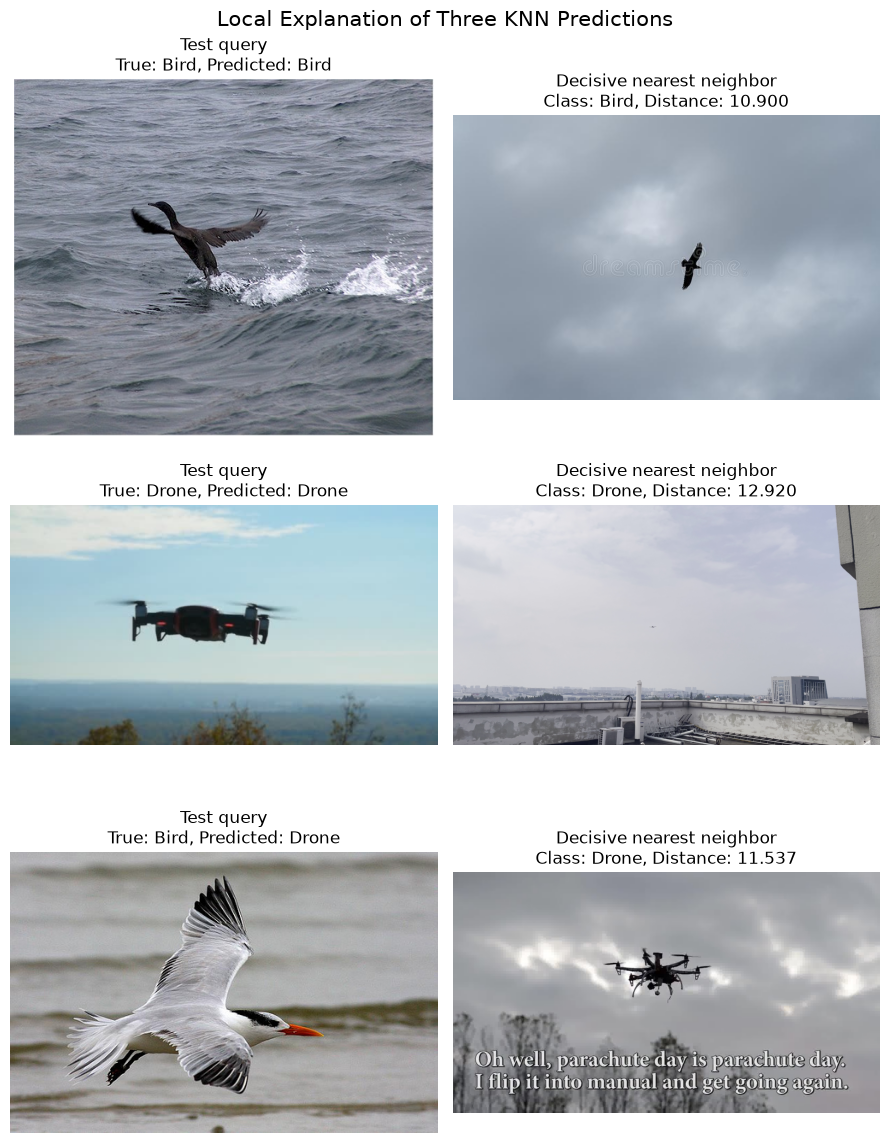

,query_image,true_class,predicted_class,nearest_image,nearest_class,manhattan_distance,correct
0,105.jpg,Bird,Bird,singleBirdinsky7.jpeg,Bird,10.900,True
1,000000000002.jpg,Drone,Drone,img_plane3_14.jpg,Drone,12.920,True
2,143.jpg,Bird,Drone,000000000146.jpg,Drone,11.537,False


In [49]:
correct_bird_index = test_results_df[
    (test_results_df["label"] == 1) &
    (test_results_df["prediction"] == 1)
].index[0]

correct_drone_index = test_results_df[
    (test_results_df["label"] == 0) &
    (test_results_df["prediction"] == 0)
].index[0]

incorrect_index = test_results_df[
    test_results_df["label"] !=
    test_results_df["prediction"]
].index[0]

explanation_test_indices = [
    correct_bird_index,
    correct_drone_index,
    incorrect_index
]

explanation_records = []

fig, axes = plt.subplots(
    3,
    2,
    figsize=(9, 12)
)

for row_number, test_index in enumerate(
    explanation_test_indices
):
    query_row = test_results_df.loc[
        test_index
    ]

    query_features = X_test_final[
        test_index
    ]

    distances = calculate_distances(
        query_features,
        X_final_training,
        best_distance_metric
    )

    nearest_index = int(
        np.argmin(distances)
    )
    
    nearest_row = final_training_df.iloc[
        nearest_index
    ]

    predicted_label = int(
        final_test_predictions[test_index]
    )

    assert (
        int(nearest_row["label"]) ==
        predicted_label
    )

    predicted_class = label_names[
        predicted_label
    ]

    with Image.open(
        query_row["path"]
    ) as query_image:
        axes[row_number, 0].imshow(
            query_image.convert("RGB")
        )

    with Image.open(
        nearest_row["path"]
    ) as neighbor_image:
        axes[row_number, 1].imshow(
            neighbor_image.convert("RGB")
        )

    axes[row_number, 0].set_title(
        "Test query\n"
        f'True: {query_row["class"]}, '
        f"Predicted: {predicted_class}"
    )

    axes[row_number, 1].set_title(
        "Decisive nearest neighbor\n"
        f'Class: {nearest_row["class"]}, '
        f'Distance: {distances[nearest_index]:.3f}'
    )

    axes[row_number, 0].axis("off")
    axes[row_number, 1].axis("off")

    explanation_records.append({
        "query_image": (
            query_row["path"].name
        ),
        "true_class": query_row["class"],
        "predicted_class": predicted_class,
        "nearest_image": (
            nearest_row["path"].name
        ),
        "nearest_class": (
            nearest_row["class"]
        ),
        "manhattan_distance": (
            distances[nearest_index]
        ),
        "correct": (
            query_row["label"] ==
            predicted_label
        )
    })

plt.suptitle(
    "Local Explanation of Three KNN Predictions",
    fontsize=15
)

plt.tight_layout()
plt.show()

explanation_df = pd.DataFrame(
    explanation_records
)

display(
    explanation_df.round(3)
)

### Explainability Interpretation

The first Bird query was classified correctly because its nearest neighbor
was also a Bird. Both images contain a flying bird against a mostly gray,
open background. The Drone query was also classified correctly because its
nearest neighbor belonged to the Drone class.

The third query demonstrates a model limitation. Although the true object is
a Bird, its nearest neighbor was a Drone, so the k=1 model predicted Drone.
The images share global color and edge characteristics, including a dark
flying object against a pale background. This indicates that the handcrafted
representation may sometimes match background and general shape patterns
instead of the semantic identity of the object.

## 6. Unsupervised Extension: K-Means Clustering

K-Means is applied as an unsupervised extension. The algorithm receives only the standardized HSV color features and does not receive the Bird and Drone labels. We use two clusters to investigate whether the images naturally separate into groups corresponding to the two known classes.

In [50]:
# Standardize the HSV color features for K-Means
color_mean = X_train_color.mean(axis=0)
color_std = X_train_color.std(axis=0)

# Prevent division by zero for constant features
color_std[color_std < 1e-8] = 1.0

X_train_color_scaled = (
    (X_train_color - color_mean) / color_std
)

print("Scaled color feature matrix:", X_train_color_scaled.shape)

Scaled color feature matrix: (2289, 48)


In [51]:
def kmeans_from_scratch(
    X,
    number_of_clusters=2,
    maximum_iterations=100,
    tolerance=1e-4,
    seed=42
):
    random_generator = np.random.default_rng(
        seed
    )

    initial_indices = random_generator.choice(
        len(X),
        size=number_of_clusters,
        replace=False
    )

    centroids = X[
        initial_indices
    ].copy()

    for iteration in range(maximum_iterations):
        squared_distances = np.sum(
            (
                X[:, np.newaxis, :]
                - centroids[np.newaxis, :, :]
            ) ** 2,
            axis=2
        )

        cluster_labels = np.argmin(
            squared_distances,
            axis=1
        )

        new_centroids = []

        for cluster_number in range(
            number_of_clusters
        ):
            cluster_members = X[
                cluster_labels == cluster_number
            ]

            if len(cluster_members) == 0:
                new_centroid = X[
                    random_generator.integers(len(X))
                ]
            else:
                new_centroid = cluster_members.mean(
                    axis=0
                )

            new_centroids.append(new_centroid)

        new_centroids = np.vstack(
            new_centroids
        )

        centroid_movement = np.linalg.norm(
            new_centroids - centroids
        )

        centroids = new_centroids

        if centroid_movement < tolerance:
            break

    final_squared_distances = np.sum(
        (
            X[:, np.newaxis, :]
            - centroids[np.newaxis, :, :]
        ) ** 2,
        axis=2
    )

    cluster_labels = np.argmin(
        final_squared_distances,
        axis=1
    )

    inertia = np.sum(
        final_squared_distances[
            np.arange(len(X)),
            cluster_labels
        ]
    )

    return (
        cluster_labels,
        centroids,
        inertia,
        iteration + 1
    )

In [52]:
actual_class_names = np.where(
    y_train == 1,
    "Bird",
    "Drone"
)

print(
    "Class labels prepared for evaluating "
    "the final K-Means solution."
)

Class labels prepared for evaluating the final K-Means solution.


In [53]:
kmeans_runs = []

best_inertia = np.inf
best_clusters = None
best_centroids = None
best_seed = None

for seed in range(10):
    (
        current_clusters,
        current_centroids,
        current_inertia,
        current_iterations
    ) = kmeans_from_scratch(
        X_train_color_scaled,
        number_of_clusters=2,
        seed=seed
    )

    current_table = pd.crosstab(
        actual_class_names,
        current_clusters
    )

    current_purity = (
        current_table.max(axis=0).sum()
        / len(y_train)
    )

    kmeans_runs.append({
        "seed": seed,
        "inertia": current_inertia,
        "iterations": current_iterations,
        "cluster_0_size": np.sum(
            current_clusters == 0
        ),
        "cluster_1_size": np.sum(
            current_clusters == 1
        ),
        "purity": current_purity
    })

    if current_inertia < best_inertia:
        best_inertia = current_inertia
        best_clusters = current_clusters
        best_centroids = current_centroids
        best_seed = seed

kmeans_runs_df = pd.DataFrame(
    kmeans_runs
).sort_values("inertia")

kmeans_runs_df

,seed,inertia,iterations,cluster_0_size,cluster_1_size,purity
0,0,100442.796875,24,1418,871,0.650502
5,5,100445.296875,14,1516,773,0.650502
6,6,100458.367188,13,1438,851,0.650502
8,8,100600.289062,8,1043,1246,0.669288
7,7,100601.054688,11,1026,1263,0.663609
2,2,100601.187500,13,1268,1021,0.657929
3,3,100617.093750,11,1149,1140,0.650502
4,4,100617.093750,16,1140,1149,0.650502
1,1,100937.890625,12,288,2001,0.650502
9,9,100965.570312,15,1912,377,0.650502


In [54]:
train_clusters = best_clusters
cluster_centroids = best_centroids

print("Best seed:", best_seed)
print("Best inertia:", best_inertia)

pd.crosstab(
    actual_class_names,
    train_clusters,
    rownames=["Actual Class"],
    colnames=["Best K-Means Cluster"],
    margins=True
)

Best seed: 0
Best inertia: 100442.8


Best K-Means Cluster,0,1,All
Actual Class,,,
Bird,633,167,800
Drone,785,704,1489
All,1418,871,2289


### K-Means Initialization Results
K-Means was executed with ten different centroid initializations. The solution with seed 0 achieved the lowest inertia. However, both of its clusters contained more drones than birds, and its purity of 0.651 was equivalent to predicting the majority class. One cluster was strongly drone-dominated, while the other remained mixed. This indicates that the color-based clusters do not directly correspond to the semantic Bird and Drone classes.

### Normalized Mutual Information

Purity can be influenced by class imbalance. Therefore, Normalized Mutual
Information (NMI) is also calculated to measure the association between the
K-Means clusters and the true Bird and Drone classes. NMI ranges from 0,
indicating no meaningful association, to 1, indicating perfect agreement.
The true labels are used only for evaluation and were not provided to K-Means.

In [55]:
def calculate_entropy(labels):
    _, counts = np.unique(
        labels,
        return_counts=True
    )

    probabilities = (
        counts / counts.sum()
    )

    return -np.sum(
        probabilities *
        np.log(probabilities)
    )


def calculate_nmi(
    true_labels,
    cluster_labels
):
    contingency = pd.crosstab(
        pd.Series(true_labels),
        pd.Series(cluster_labels)
    ).to_numpy(dtype=np.float64)

    joint_probability = (
        contingency / contingency.sum()
    )

    true_probability = (
        joint_probability.sum(axis=1)
    )

    cluster_probability = (
        joint_probability.sum(axis=0)
    )

    expected_probability = np.outer(
        true_probability,
        cluster_probability
    )

    nonzero = joint_probability > 0

    mutual_information = np.sum(
        joint_probability[nonzero] *
        np.log(
            joint_probability[nonzero] /
            expected_probability[nonzero]
        )
    )

    denominator = np.sqrt(
        calculate_entropy(true_labels) *
        calculate_entropy(cluster_labels)
    )

    if denominator == 0:
        return 0.0

    return mutual_information / denominator


nmi_score = calculate_nmi(
    y_train,
    best_clusters
)

print(f"NMI score: {nmi_score:.4f}")

NMI score: 0.0539


### Silhouette Score

The silhouette score evaluates cluster cohesion and separation without using
the true Bird and Drone labels. Values close to 1 indicate compact and
well-separated clusters, values near 0 indicate overlapping clusters, and
negative values indicate that some examples may be closer to another cluster.

In [56]:
def calculate_silhouette_score(
    X,
    cluster_labels
):
    X = np.asarray(
        X,
        dtype=np.float32
    )

    cluster_labels = np.asarray(
        cluster_labels
    )

    unique_clusters = np.unique(
        cluster_labels
    )

    if len(unique_clusters) < 2:
        raise ValueError(
            "Silhouette score requires "
            "at least two clusters."
        )

    squared_norms = np.sum(
        X ** 2,
        axis=1
    )

    squared_distances = (
        squared_norms[:, np.newaxis]
        + squared_norms[np.newaxis, :]
        - 2 * X @ X.T
    )

    squared_distances = np.maximum(
        squared_distances,
        0
    )

    distance_matrix = np.sqrt(
        squared_distances
    )

    silhouette_values = []

    for index in range(len(X)):
        same_cluster = (
            cluster_labels ==
            cluster_labels[index]
        )

        same_cluster[index] = False

        if same_cluster.sum() == 0:
            silhouette_values.append(0.0)
            continue

        mean_inside_distance = (
            distance_matrix[
                index,
                same_cluster
            ].mean()
        )

        other_cluster_distances = []

        for cluster in unique_clusters:
            if cluster == cluster_labels[index]:
                continue

            other_cluster_distances.append(
                distance_matrix[
                    index,
                    cluster_labels == cluster
                ].mean()
            )

        nearest_other_distance = min(
            other_cluster_distances
        )

        denominator = max(
            mean_inside_distance,
            nearest_other_distance
        )

        silhouette_value = (
            (
                nearest_other_distance
                - mean_inside_distance
            ) / denominator
            if denominator > 0
            else 0.0
        )

        silhouette_values.append(
            silhouette_value
        )

    return float(
        np.mean(silhouette_values)
    )


silhouette_score = (
    calculate_silhouette_score(
        X_train_color_scaled,
        best_clusters
    )
)

print(
    f"Silhouette score: "
    f"{silhouette_score:.4f}"
)

Silhouette score: 0.0924


### Clustering Metrics Interpretation

The NMI score of 0.0539 indicates only a very weak association between the
K-Means clusters and the true Bird and Drone classes. The silhouette score of
0.0924 also indicates weak separation and substantial overlap between the
two clusters. Together with the purity result, these metrics show that the
clusters mainly capture visual background and color patterns rather than the
semantic object classes.

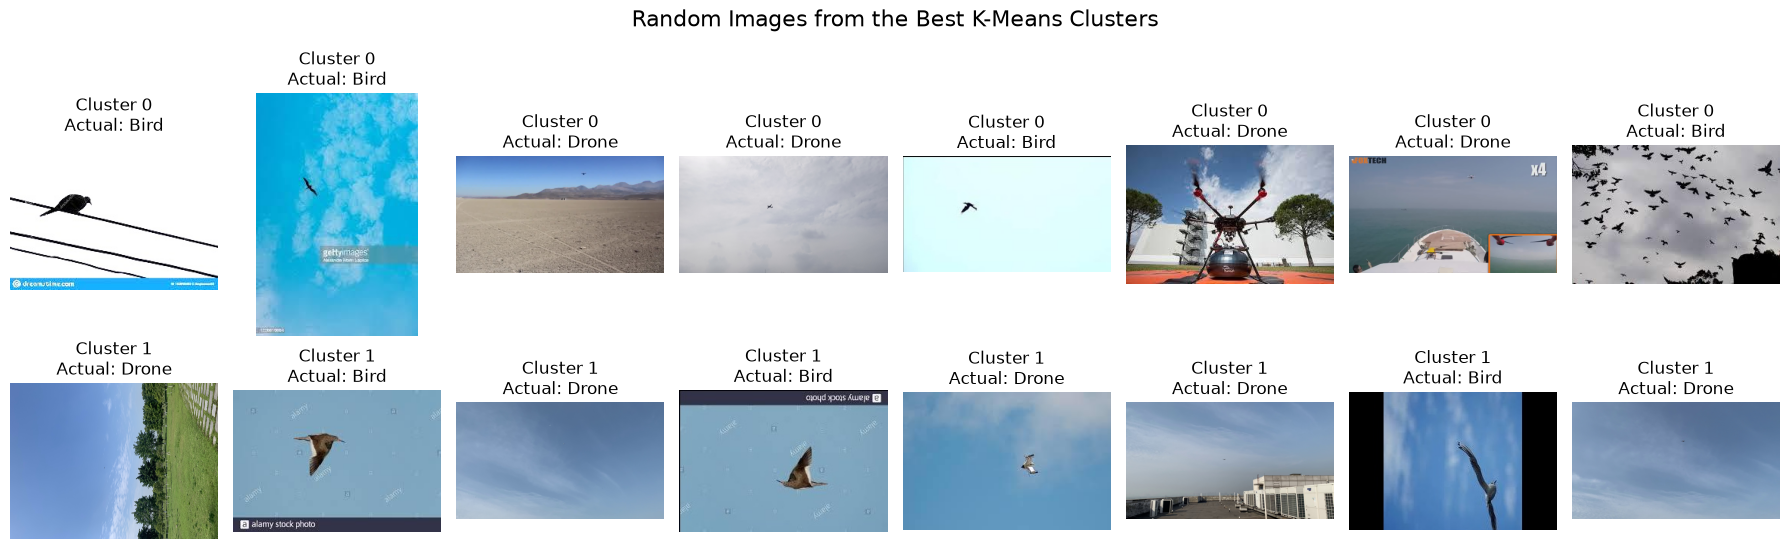

In [57]:
clustered_train_df = train_df.copy()

clustered_train_df["cluster"] = (
    train_clusters
)

cluster_zero_samples = clustered_train_df[
    clustered_train_df["cluster"] == 0
].sample(8, random_state=42)

cluster_one_samples = clustered_train_df[
    clustered_train_df["cluster"] == 1
].sample(8, random_state=42)

fig, axes = plt.subplots(
    2,
    8,
    figsize=(18, 6)
)

for column, (_, row) in enumerate(
    cluster_zero_samples.iterrows()
):
    with Image.open(row["path"]) as image:
        axes[0, column].imshow(
            image.convert("RGB")
        )

    axes[0, column].set_title(
        f'Cluster 0\nActual: {row["class"]}'
    )
    axes[0, column].axis("off")

for column, (_, row) in enumerate(
    cluster_one_samples.iterrows()
):
    with Image.open(row["path"]) as image:
        axes[1, column].imshow(
            image.convert("RGB")
        )

    axes[1, column].set_title(
        f'Cluster 1\nActual: {row["class"]}'
    )
    axes[1, column].axis("off")

plt.suptitle(
    "Random Images from the Best K-Means Clusters",
    fontsize=16
)
plt.tight_layout()
plt.show()

### Visual Interpretation of the Clusters

The sample images indicate that K-Means primarily separated images according to background appearance. Cluster 1 contains many images with smooth blue or gray skies, while Cluster 0 contains more varied backgrounds, including white skies, land, water, vegetation and strongly saturated colors. Both birds and drones appear in each cluster. Therefore, the unsupervised color representation captures environmental appearance more strongly than object identity.

In [58]:
def pca_to_two_dimensions(X):
    centered_data = X - X.mean(axis=0)

    _, singular_values, components = (
        np.linalg.svd(
            centered_data,
            full_matrices=False
        )
    )

    two_components = components[:2]

    coordinates = (
        centered_data @ two_components.T
    )

    explained_variance = (
        singular_values ** 2
    )

    explained_variance_ratio = (
        explained_variance /
        explained_variance.sum()
    )

    return (
        coordinates,
        explained_variance_ratio[:2]
    )


pca_coordinates, explained_ratio = (
    pca_to_two_dimensions(
        X_train_color_scaled
    )
)

print(
    "Variance explained by two components:",
    explained_ratio.sum()
)

Variance explained by two components: 0.20619605


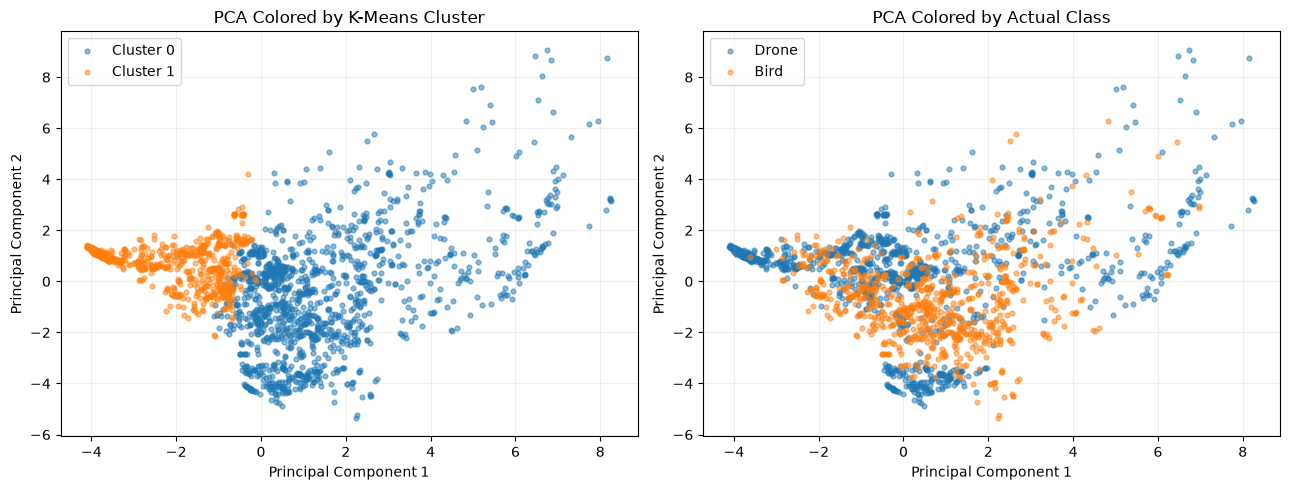

In [59]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

for cluster_number in [0, 1]:
    mask = train_clusters == cluster_number

    axes[0].scatter(
        pca_coordinates[mask, 0],
        pca_coordinates[mask, 1],
        s=12,
        alpha=0.5,
        label=f"Cluster {cluster_number}"
    )

for label, class_name in [
    (0, "Drone"),
    (1, "Bird")
]:
    mask = y_train == label

    axes[1].scatter(
        pca_coordinates[mask, 0],
        pca_coordinates[mask, 1],
        s=12,
        alpha=0.5,
        label=class_name
    )

axes[0].set_title("PCA Colored by K-Means Cluster")
axes[1].set_title("PCA Colored by Actual Class")

for axis in axes:
    axis.set_xlabel("Principal Component 1")
    axis.set_ylabel("Principal Component 2")
    axis.legend()
    axis.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### PCA Interpretation

The first two principal components explain approximately 20.6% of the total variance, so the two-dimensional visualization represents only part of the original 48-dimensional feature space. The K-Means clusters form visible geometric regions, while the actual Bird and Drone labels overlap considerably. K-Means found structure in the color features, but this structure does not match the Bird and Drone labels.

## 7. Conclusion

This project tested whether handcrafted image features and KNN can distinguish birds from drones. Exact duplicates were removed, and related images were kept in the same data split to reduce leakage. The comparison included grayscale pixels, HSV color histograms, edge features and combined HSV-and-edge features.

The best configuration before class balancing used combined HSV-and-edge features, k=1, uniform voting and Manhattan distance. It achieved a mean cross-validation accuracy of 0.9033 and a mean Bird F1-score of 0.8568. Random undersampling increased mean Bird F1-score slightly to 0.8587, while mean accuracy decreased to 0.9005. Since Bird F1-score was selected as the main metric in advance, the undersampled model was used for the final evaluation.

On the held-out test set, the selected model achieved 0.9035 accuracy and a Bird F1-score of 0.8555. It correctly classified 480 of 524 drones and 222 of 253 birds. Most errors involved small, blurred or low-contrast objects. The nearest-neighbor examples also showed that background color and strong edges sometimes affected the prediction more than the object itself.

K-Means did not recover the two semantic classes from the HSV features. Its purity was 0.651, NMI was 0.0539 and the silhouette score was 0.0924. The cluster examples and PCA visualization showed that the clusters were based mainly on color and background characteristics.